In [2]:
import networkx as nx
import matplotlib.pyplot as plt

In [5]:
# Load Facebook network
fb_graph = nx.read_edgelist("facebook_combined.txt")

print("Facebook Network")
print("Nodes:", fb_graph.number_of_nodes())
print("Edges:", fb_graph.number_of_edges())

Facebook Network
Nodes: 4039
Edges: 88234


In [6]:
# Load YouTube network
yt_graph = nx.read_edgelist("com-youtube.ungraph.txt")

print("\nYouTube Network")
print("Nodes:", yt_graph.number_of_nodes())
print("Edges:", yt_graph.number_of_edges())


YouTube Network
Nodes: 1134890
Edges: 2987624


In [7]:
def analyze_graph(G, name):
    print(f"\n--- {name} ---")
    print("Number of Nodes:", G.number_of_nodes())
    print("Number of Edges:", G.number_of_edges())
    print("Network Density:", nx.density(G))
    
    # Degree centrality
    centrality = nx.degree_centrality(G)
    top_nodes = sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:5]
    print("Top 5 nodes by degree centrality:", top_nodes)

# Analyze both
analyze_graph(fb_graph, "Facebook")
analyze_graph(yt_graph, "YouTube")


--- Facebook ---
Number of Nodes: 4039
Number of Edges: 88234
Network Density: 0.010819963503439287
Top 5 nodes by degree centrality: [('107', 0.258791480931154), ('1684', 0.1961367013372957), ('1912', 0.18697374938088163), ('3437', 0.13546310054482416), ('0', 0.08593363051015354)]

--- YouTube ---
Number of Nodes: 1134890
Number of Edges: 2987624
Network Density: 4.639260713241579e-06
Top 5 nodes by degree centrality: [('1072', 0.025336398537654344), ('363', 0.012900821137573806), ('35661', 0.009940179171707541), ('106', 0.009217641549085418), ('482709', 0.008601722282972167)]


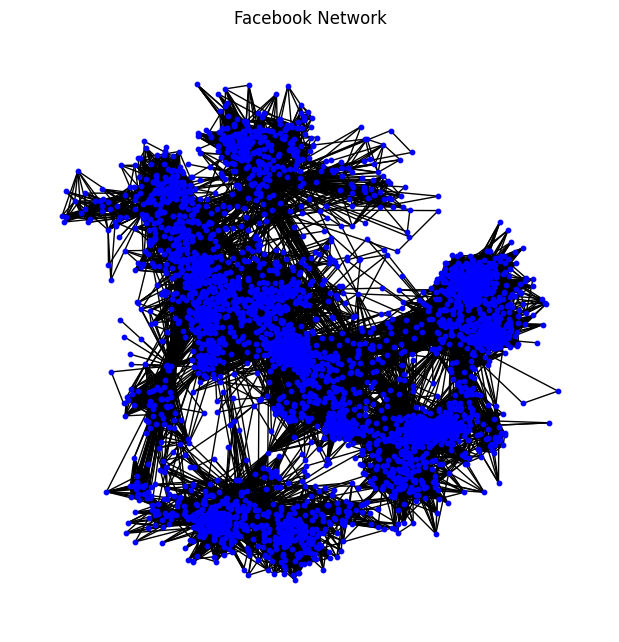

In [9]:
plt.figure(figsize=(6,6))
nx.draw(fb_graph, node_size=10, node_color="blue")
plt.title("Facebook Network")
plt.show()

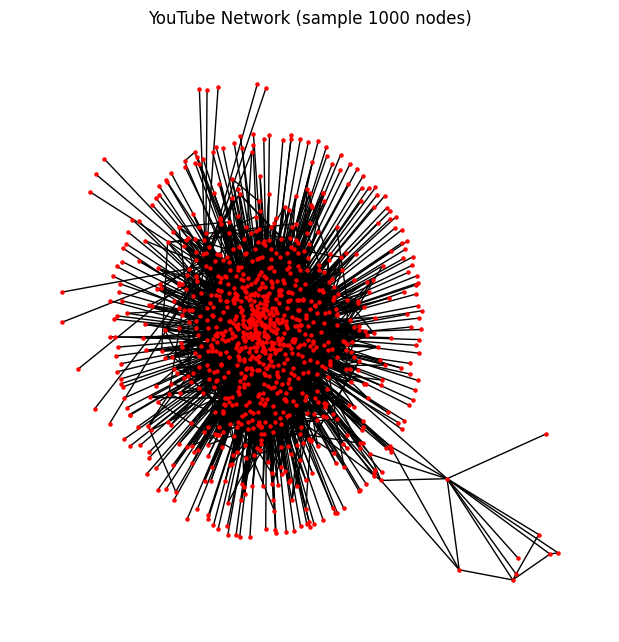

In [10]:
sample_nodes = list(yt_graph.nodes())[:1000]
subgraph = yt_graph.subgraph(sample_nodes)

plt.figure(figsize=(6,6))
nx.draw(subgraph, node_size=5, node_color="red")
plt.title("YouTube Network (sample 1000 nodes)")
plt.show()

In [11]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

In [12]:
# Load Facebook
fb_graph = nx.read_edgelist("facebook_combined.txt")

# Load YouTube
yt_graph = nx.read_edgelist("com-youtube.ungraph.txt")


--- Facebook ---
Number of Nodes: 4039
Number of Edges: 88234
Mean Degree: 43.69101262688784
Minimum Degree: 1
Maximum Degree: 1045
Median Degree: 25.0
Standard Deviation of Degree: 52.41411556737521


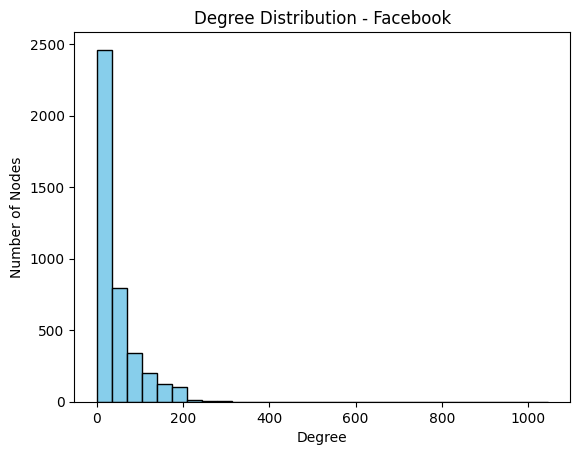


--- YouTube (sample visualization) ---
Number of Nodes: 1134890
Number of Edges: 2987624
Mean Degree: 5.265045951590022
Minimum Degree: 1
Maximum Degree: 28754
Median Degree: 1.0
Standard Deviation of Degree: 50.754342910669784


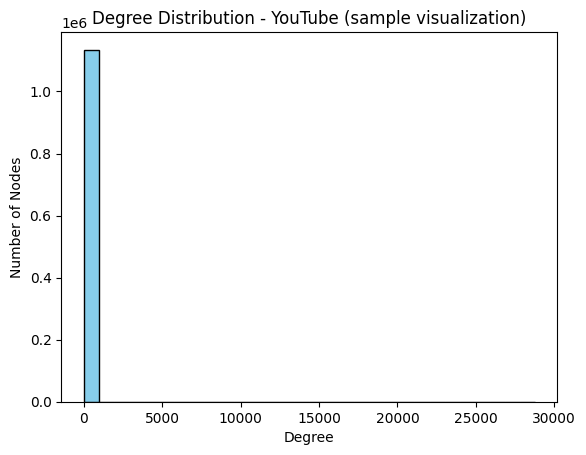

In [13]:
def degree_statistics(G, name):
    degrees = [deg for node, deg in G.degree()]
    
    mean_deg = np.mean(degrees)
    min_deg = np.min(degrees)
    max_deg = np.max(degrees)
    std_deg = np.std(degrees)
    median_deg = np.median(degrees)
    
    print(f"\n--- {name} ---")
    print("Number of Nodes:", G.number_of_nodes())
    print("Number of Edges:", G.number_of_edges())
    print("Mean Degree:", mean_deg)
    print("Minimum Degree:", min_deg)
    print("Maximum Degree:", max_deg)
    print("Median Degree:", median_deg)
    print("Standard Deviation of Degree:", std_deg)
    
    # Optional: plot degree distribution
    plt.figure()
    plt.hist(degrees, bins=30, color="skyblue", edgecolor="black")
    plt.title(f"Degree Distribution - {name}")
    plt.xlabel("Degree")
    plt.ylabel("Number of Nodes")
    plt.show()

# Run for both datasets
degree_statistics(fb_graph, "Facebook")
degree_statistics(yt_graph, "YouTube (sample visualization)")

In [14]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import csv

# =========================
# Class for Network Analysis
# =========================
class SocialNetwork:
    def __init__(self, file_path, name):
        self.file_path = file_path
        self.name = name
        self.graph = nx.Graph()
        self.degrees = []

    # Function to load graph from file
    def load_graph(self):
        try:
            self.graph = nx.read_edgelist(self.file_path)
            self.degrees = [deg for node, deg in self.graph.degree()]
            print(f"{self.name} graph loaded successfully!")
        except Exception as e:
            print(f"Error loading graph: {e}")

    # Function to compute summary statistics
    def compute_statistics(self):
        stats = {}
        stats['Nodes'] = self.graph.number_of_nodes()
        stats['Edges'] = self.graph.number_of_edges()
        stats['Mean Degree'] = np.mean(self.degrees)
        stats['Min Degree'] = np.min(self.degrees)
        stats['Max Degree'] = np.max(self.degrees)
        stats['Median Degree'] = np.median(self.degrees)
        stats['Std Degree'] = np.std(self.degrees)
        stats['Density'] = nx.density(self.graph)
        stats['Avg Clustering'] = nx.average_clustering(self.graph)
        return stats

    # Function to get top central nodes
    def top_central_nodes(self, n=5):
        centrality = nx.degree_centrality(self.graph)
        top_nodes = sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:n]
        return top_nodes

    # Function to save statistics to CSV
    def save_statistics_csv(self, stats, filename):
        try:
            with open(filename, mode='w', newline='') as file:
                writer = csv.writer(file)
                writer.writerow(["Metric", "Value"])
                for key, value in stats.items():
                    writer.writerow([key, value])
            print(f"Statistics saved to {filename}")
        except Exception as e:
            print(f"Error saving CSV: {e}")

    # Function to plot degree distribution
    def plot_degree_distribution(self):
        plt.figure(figsize=(6,6))
        plt.hist(self.degrees, bins=30, color='skyblue', edgecolor='black')
        plt.title(f"Degree Distribution - {self.name}")
        plt.xlabel("Degree")
        plt.ylabel("Number of Nodes")
        plt.show()


# =========================
# Main Program
# =========================
def main():
    # Create objects for Facebook and YouTube
    facebook = SocialNetwork("facebook_combined.txt", "Facebook")
    youtube = SocialNetwork("com-youtube.ungraph.txt", "YouTube")

    # Load graphs
    facebook.load_graph()
    youtube.load_graph()

    # Compute statistics
    fb_stats = facebook.compute_statistics()
    yt_stats = youtube.compute_statistics()

    # Print statistics
    print("\nFacebook Statistics:", fb_stats)
    print("\nYouTube Statistics:", yt_stats)

    # Save statistics to CSV
    facebook.save_statistics_csv(fb_stats, "facebook_stats.csv")
    youtube.save_statistics_csv(yt_stats, "youtube_stats.csv")

    # Top 5 central nodes
    print("\nTop 5 central nodes in Facebook:", facebook.top_central_nodes())
    print("Top 5 central nodes in YouTube:", youtube.top_central_nodes())

    # Plot degree distribution
    facebook.plot_degree_distribution()
    # For YouTube, optional: plot a sample to avoid huge plot
    sample_nodes = list(youtube.graph.nodes())[:1000]
    sample_graph = youtube.graph.subgraph(sample_nodes)
    youtube_sample = SocialNetwork("", "YouTube Sample")
    youtube_sample.graph = sample_graph
    youtube_sample.degrees = [deg for node, deg in sample_graph.degree()]
    youtube_sample.plot_degree_distribution()


if __name__ == "__main__":
    main()

Facebook graph loaded successfully!
YouTube graph loaded successfully!


KeyboardInterrupt: 